✨ دقت مدل (R2 Score): 0.9815
🎯 میانگین خطای پیش‌بینی (MAE): 1.50 گرم


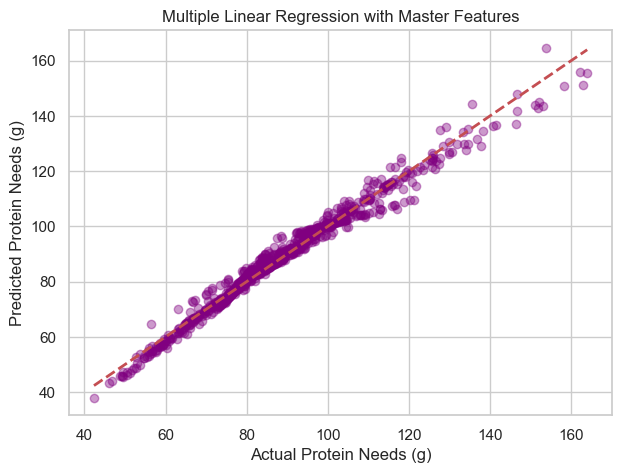

In [10]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ۱. بارگذاری دیتاست مستر
df_master = pd.read_csv('../data/processed/NHANES_Master_Dataset.csv')

# ۲. آماده‌سازی متغیرها (تبدیل جنسیت به عددی)
df_master['Is_Male'] = df_master['Gender'].map({'Male': 1, 'Female': 0})

# ۳. تفکیک ویژگی‌ها و هدف
features = ['Age', 'Is_Male', 'Weight_kg', 'Height_cm', 'BMI', 'Body_Fat_Percent', 'Lean_Mass_kg', 'Activity_Score', 'Daily_Protein_Intake_g', 'Genetic_Score']
X = df_master[features]
y = df_master['Protein_Requirement_g']

# ۴. تقسیم داده‌ها به قطعات آموزش و تست (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ۵. ساخت و آموزش مدل
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# ۶. پیش‌بینی و ارزیابی
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = np.mean(abs(y_test - y_pred))

print(f"✨ دقت مدل (R2 Score): {r2:.4f}")
print(f"🎯 میانگین خطای پیش‌بینی (MAE): {mae:.2f} گرم")

# ۷. رسم نمودار مقایسه
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Protein Needs (g)')
plt.ylabel('Predicted Protein Needs (g)')
plt.title('Multiple Linear Regression with Master Features')
plt.grid(True)
plt.show()

In [11]:
import pandas as pd
import numpy as np
import pylab as pl
import os
import warnings
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline

df=pd.read_csv('../data/processed/NHANES_Master_Dataset.csv')
cdf=df[['Age','Activity_Level','BMI','Gender','Height_cm','Weight_kg','Body_Fat_Percent','Lean_Mass_kg','Activity_Score','Daily_Protein_Intake_g','Genetic_Score','Protein_Requirement_g']]
df.head()

,ID,Age,Gender,Weight_kg,Height_cm,BMI,Body_Fat_Percent,Lean_Mass_kg,Activity_Level,Activity_Score,Daily_Protein_Intake_g,Genetic_Score,Protein_Requirement_g
0,93705.0,66.0,Female,79.5,158.3,31.7,33.1,49.58,Light,2,29.26,91.77,84.57
1,93706.0,18.0,Male,66.3,175.7,21.5,22.7,48.77,Light,2,94.19,90.89,80.87
2,93708.0,66.0,Female,53.5,150.2,23.7,33.1,49.58,Light,2,41.90,94.76,79.67
3,93709.0,75.0,Female,88.8,151.1,38.9,33.1,49.58,Sedentary,1,72.16,92.09,77.58
4,93711.0,56.0,Male,62.1,170.6,21.3,22.8,45.73,Active,4,88.07,93.84,89.10


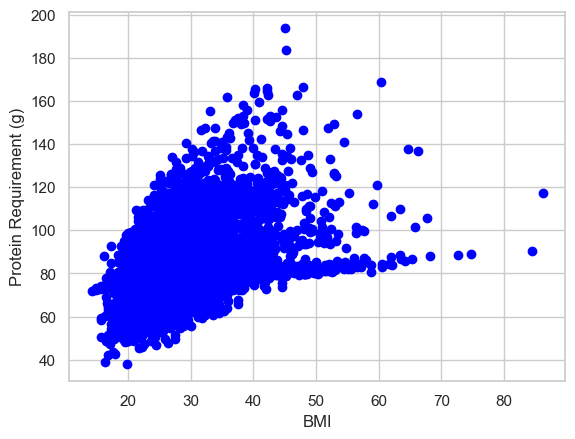

In [12]:
plt.scatter(cdf.BMI, cdf.Protein_Requirement_g, color='blue')
plt.xlabel("BMI")
plt.ylabel("Protein Requirement (g)")
plt.show()

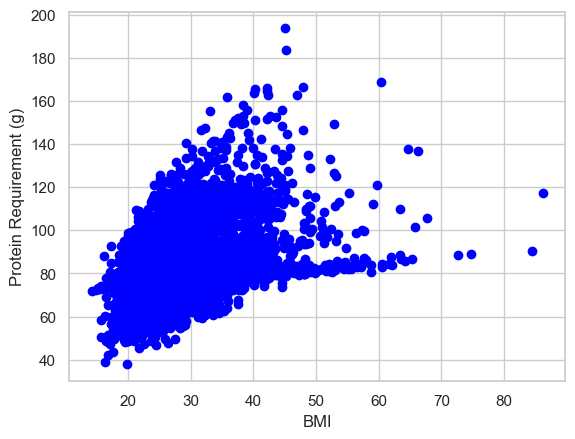

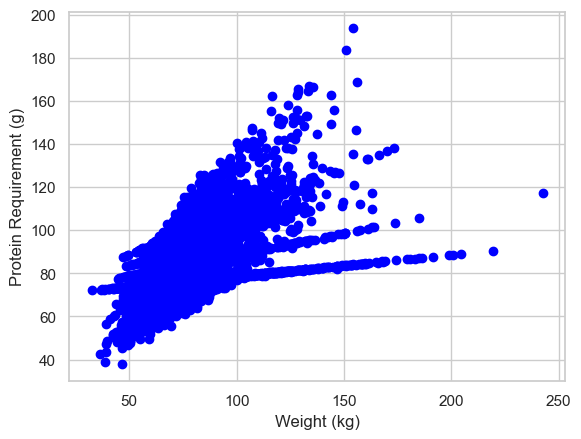

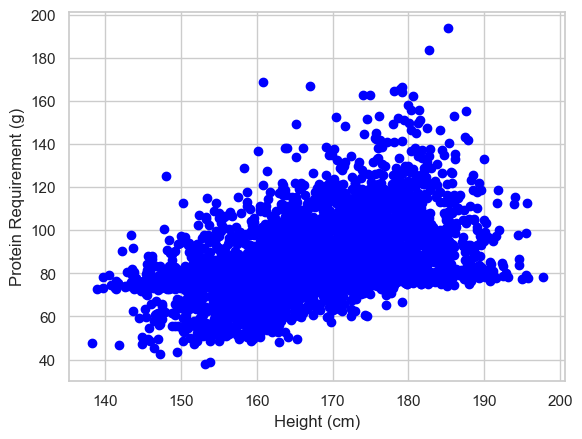

In [13]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]
plt.scatter(train.BMI, train.Protein_Requirement_g, color='blue')
plt.xlabel("BMI")
plt.ylabel("Protein Requirement (g)")
plt.show()
plt.scatter(train.Weight_kg, train.Protein_Requirement_g, color='blue')
plt.xlabel("Weight (kg)")
plt.ylabel("Protein Requirement (g)")
plt.show()
plt.scatter(train.Height_cm, train.Protein_Requirement_g, color='blue')
plt.xlabel("Height (cm)")
plt.ylabel("Protein Requirement (g)")
plt.show()

In [14]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
x=np.asanyarray(train[['Age','BMI','Height_cm','Weight_kg','Body_Fat_Percent','Lean_Mass_kg','Activity_Score','Daily_Protein_Intake_g','Genetic_Score']])
y=np.asanyarray(train[['Protein_Requirement_g']])
regr.fit(x, y)
print('Coefficients: ', regr.coef_)
print('Intercept: ', regr.intercept_)

Coefficients:  [[ 4.59574854e-03 -2.26828198e-01 -6.92940714e-02  2.37232501e-01
   7.41898417e-02  1.28005754e+00  8.16869531e+00 -1.78232660e-03
   9.35765163e-02]]
Intercept:  [-7.22596804]


Mean absolute error: 1.46
Residual sum of squares (MSE): 5.61
Variance score: 0.98
R2-score: 0.98


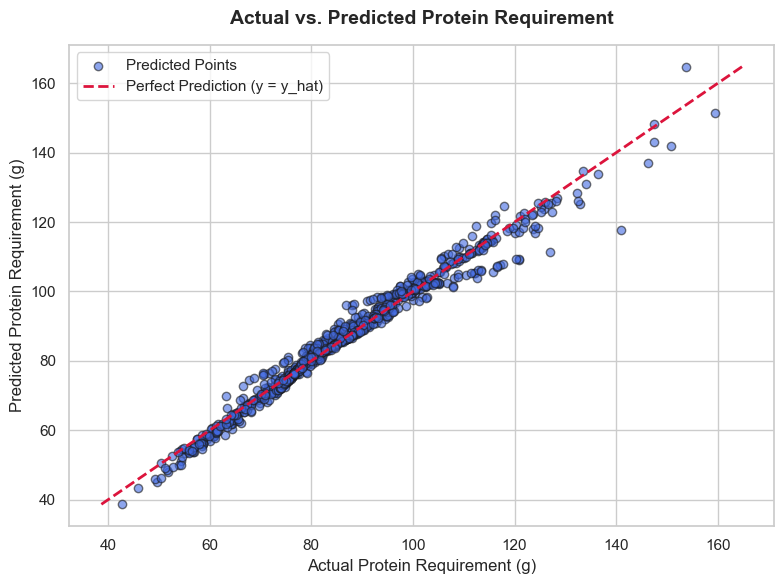

In [15]:
y_hat = regr.predict(np.asanyarray(test[['Age', 'BMI', 'Height_cm', 'Weight_kg', 'Body_Fat_Percent', 'Lean_Mass_kg', 'Activity_Score','Daily_Protein_Intake_g','Genetic_Score']]))
x = np.asanyarray(test[['Age','BMI','Height_cm','Weight_kg','Body_Fat_Percent','Lean_Mass_kg','Activity_Score','Daily_Protein_Intake_g','Genetic_Score']])
y = np.asanyarray(test[['Protein_Requirement_g']])
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_hat - y) ** 2))
print('Variance score: %.2f' % regr.score(x, y))
print('R2-score: %.2f' % r2_score(y, y_hat))
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
plt.scatter(y, y_hat, color='royalblue', alpha=0.6, edgecolors='k', label='Predicted Points')
max_val = max(max(y.flatten()), max(y_hat.flatten()))
min_val = min(min(y.flatten()), min(y_hat.flatten()))
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label='Perfect Prediction (y = y_hat)')
plt.title('Actual vs. Predicted Protein Requirement', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Protein Requirement (g)', fontsize=12)
plt.ylabel('Predicted Protein Requirement (g)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
def predict_my_protein_9_features(age, activity_level, bmi, gender, height, weight, body_fat, lean_mass, activity_score):
    my_features = np.asanyarray([[age, activity_level, bmi, gender, height, weight, body_fat, lean_mass, activity_score]])
    predicted_protein = regr.predict(my_features)[0][0]
    print("=" * 40)
    print("   📊 نتایج مدل پیش‌بینی نهایی (۹ معیاره - دقت ۰.۹۸)   ")
    print("=" * 40)
    print(f"🟢 میزان پروتئین مورد نیاز بدن شما: {predicted_protein:.2f} gram/day")
    print("=" * 40)
    return predicted_protein
predict_my_protein_9_features(
    age = 25,
    activity_level = 3,
    bmi = 23.5,
    gender = 1,
    height = 180.0,
    weight = 76.0,
    body_fat = 16.5,
    lean_mass = 60.0,
    activity_score = 3
)

   📊 نتایج مدل پیش‌بینی نهایی (۹ معیاره - دقت ۰.۹۸)   
🟢 میزان پروتئین مورد نیاز بدن شما: 236.41 gram/day


np.float64(236.4130695924425)

In [26]:
model_dir = r"C:\Windows\System32\protein-recommendation-ai\protein-recommendation-ai\models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
model_path = os.path.join(model_dir, "multiple_linear_regression_model.pkl")
joblib.dump(regr, model_path)
print(f"✨ مدل 'regr' با موفقیت در مسیر زیر ذخیره شد:\n{model_path}")

✨ مدل 'regr' با موفقیت در مسیر زیر ذخیره شد:
C:\Windows\System32\protein-recommendation-ai\protein-recommendation-ai\models\multiple_linear_regression_model.pkl
